# Optimisation de LightGBM et du seuil métier

Ce notebook optimise LightGBM en comparant plusieurs combinaisons d'hyperparamètres et plusieurs seuils de décision. Le couple qui minimise le coût métier moyen 10 × FN + FP sur les 5 folds sera retenu.

## Chargement et séparation des données

In [1]:
# ---------- Bibliothèques ----------
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, confusion_matrix, f1_score, recall_score, roc_auc_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline

# ---------- Configuration des données ----------
DATA_PATH = Path("../data/processed/application_train_final_encoded.csv")
ID_COLUMN = "SK_ID_CURR"
TARGET_COLUMN = "TARGET"
RANDOM_STATE = 42

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Fichier introuvable : {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
required_columns = {ID_COLUMN, TARGET_COLUMN}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Colonnes obligatoires absentes : {sorted(missing_columns)}")

X = df.drop(columns=[ID_COLUMN, TARGET_COLUMN])
y = df[TARGET_COLUMN]

# 80 % servent à l'entraînement et à la validation croisée ; 20 % restent intouchés pour l'évaluation finale.
X_train, X_final, y_train, y_final = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Entraînement : {len(X_train):,} lignes")
print(f"Évaluation finale : {len(X_final):,} lignes")
print(f"Poids de la classe 1 : {SCALE_POS_WEIGHT:.2f}")

Entraînement : 246,008 lignes
Évaluation finale : 61,502 lignes
Poids de la classe 1 : 11.39


## Preprocessing et coût métier

L'imputation médiane est apprise uniquement pendant l'entraînement. Le coût métier pénalise un faux négatif dix fois plus qu'un faux positif.

In [2]:
# ---------- Pipeline LightGBM ----------
def create_lightgbm_pipeline(model_params):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", LGBMClassifier(**model_params)),
    ])


# ---------- Coût métier ----------
FN_COST = 10
FP_COST = 1
THRESHOLDS = [value / 100 for value in range(10, 91, 5)]

def business_cost(y_true, y_pred):
    """Calcule le coût métier : 10 × FN + 1 × FP."""
    _, fp, fn, _ = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return FN_COST * fn + FP_COST * fp


# ---------- Métriques d'évaluation ----------
def evaluate_predictions(y_true, y_pred, y_score):
    _, fp, fn, _ = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()
    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "recall": recall_score(y_true, y_pred, pos_label=1),
        "f1_score": f1_score(y_true, y_pred, pos_label=1),
        "fn": int(fn),
        "fp": int(fp),
        "business_cost": int(business_cost(y_true, y_pred)),
    }

## Optimisation des hyperparamètres

GridSearchCV entraîne chaque combinaison sur cinq folds stratifiés. Pour chaque fold, le scorer calcule une seule fois les probabilités, puis les réutilise pour évaluer tous les seuils. Seul le coût métier détermine le meilleur couple hyperparamètres-seuil.

In [3]:
# ---------- Scorer métier multi-seuils ----------
# Pour chaque fold, on récupère les probabilités une seule fois,
# puis on calcule le coût métier pour tous les seuils testés.
def threshold_business_cost_scorer(estimator, X_validation, y_validation):
    probabilities = estimator.predict_proba(X_validation)[:, 1]

    return {
        f"business_cost_{threshold:.2f}": -business_cost(
            y_validation, (probabilities >= threshold).astype(int)
        )
        for threshold in THRESHOLDS
    }


# ---------- Paramètres fixes de LightGBM ----------
# Ces paramètres restent identiques pour toutes les combinaisons testées.
GRID_MODEL_PARAMS = {
    "boosting_type": "gbdt",
    "objective": "binary",
    "scale_pos_weight": SCALE_POS_WEIGHT,
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
    "verbosity": -1,
}


# ---------- Hyperparamètres à tester ----------
PARAM_GRID = {
    "classifier__n_estimators": [100, 300],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__num_leaves": [15, 31],
    "classifier__min_child_samples": [20, 50],
}


# ---------- Validation croisée ----------
# Chaque combinaison est évaluée sur 5 folds stratifiés.
CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)


# ---------- Lancement du GridSearchCV ----------
# GridSearchCV entraîne les 16 combinaisons sur les 5 folds,
# soit 80 entraînements au total.
# refit=False : le modèle final sera réentraîné manuellement plus tard.
grid_search = GridSearchCV(
    estimator=create_lightgbm_pipeline(GRID_MODEL_PARAMS),
    param_grid=PARAM_GRID,
    scoring=threshold_business_cost_scorer,
    cv=CV,
    refit=False,
    n_jobs=-1,
    verbose=2,
)

grid_search.fit(X_train, y_train)


# ---------- Mise en forme des résultats ----------
# cv_results_ est difficile à lire directement.
# On construit donc une ligne par couple :
# hyperparamètres + seuil + coût moyen sur les 5 folds.
result_rows = []

for combination_id, params in enumerate(
    grid_search.cv_results_["params"],
    start=1,
):
    model_params = {
        name.replace("classifier__", ""): value
        for name, value in params.items()
    }

    for threshold in THRESHOLDS:
        metric_name = f"business_cost_{threshold:.2f}"

        result_rows.append({
            "combination_id": combination_id,
            **model_params,
            "threshold": threshold,

            # Moyenne du coût métier sur les 5 folds.
            # Le signe négatif est retiré pour retrouver un coût positif.
            "cv_business_cost_mean": -grid_search.cv_results_[
                f"mean_test_{metric_name}"
            ][combination_id - 1],

            # Variabilité du coût entre les 5 folds.
            "cv_business_cost_std": grid_search.cv_results_[
                f"std_test_{metric_name}"
            ][combination_id - 1],
        })


# ---------- Tableau final des couples testés ----------
# Le coût le plus faible apparaît en premier.
threshold_cv_results = (
    pd.DataFrame(result_rows)
    .sort_values("cv_business_cost_mean")
    .reset_index(drop=True)
)

display(threshold_cv_results)


# ---------- Sélection du meilleur couple ----------
# La première ligne correspond au coût métier moyen le plus faible.
best_result = threshold_cv_results.iloc[0]

BEST_GRID_PARAMS = {
    "n_estimators": int(best_result["n_estimators"]),
    "learning_rate": float(best_result["learning_rate"]),
    "num_leaves": int(best_result["num_leaves"]),
    "min_child_samples": int(best_result["min_child_samples"]),
}

BEST_THRESHOLD = float(best_result["threshold"])
BEST_CV_BUSINESS_COST = float(
    best_result["cv_business_cost_mean"]
)


# ---------- Résumé du meilleur résultat ----------
print("Meilleurs paramètres :", BEST_GRID_PARAMS)
print(f"Meilleur seuil : {BEST_THRESHOLD:.2f}")
print(
    f"Meilleur coût métier CV : "
    f"{BEST_CV_BUSINESS_COST:,.0f}"
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


KeyboardInterrupt: 

## Entraînement du meilleur modèle

In [ ]:
# ---------- Configuration finale ----------
OPTIMIZED_PARAMS = {
    **GRID_MODEL_PARAMS,
    **BEST_GRID_PARAMS,
    "n_jobs": -1,
}

optimized_model = create_lightgbm_pipeline(OPTIMIZED_PARAMS)
optimized_model.fit(X_train, y_train)

## Interprétation du seuil métier retenu

On ne cherche plus le seuil ici. Il a déjà été choisi pendant la validation croisée. Cette cellule sert uniquement à visualiser pourquoi ce seuil a été retenu pour la meilleure combinaison d’hyperparamètres.

In [ ]:
# ---------- Courbe CV de la meilleure combinaison ----------
# On récupère uniquement les résultats correspondant
# à la meilleure combinaison d'hyperparamètres trouvée précédemment.
best_combination_id = int(best_result["combination_id"])

threshold_results = (
    threshold_cv_results[
        threshold_cv_results["combination_id"].eq(best_combination_id)
    ]
    [["threshold", "cv_business_cost_mean"]]
    .sort_values("threshold")
)


# ---------- Visualisation du coût selon le seuil ----------
# Le graphique montre comment évolue le coût métier moyen
# quand on change le seuil de décision.
_, cost_axis = plt.subplots(figsize=(8, 4))

cost_axis.plot(
    threshold_results["threshold"],
    threshold_results["cv_business_cost_mean"],
    marker="o",
)


# ---------- Mise en évidence du seuil retenu ----------
# La ligne rouge indique le seuil ayant obtenu
# le coût métier moyen le plus faible pendant la CV.
cost_axis.axvline(
    BEST_THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Seuil retenu : {BEST_THRESHOLD:.2f}",
)

cost_axis.set(
    title="Coût métier CV moyen selon le seuil",
    xlabel="Seuil",
    ylabel=f"Coût CV moyen ({FN_COST} × FN + {FP_COST} × FP)",
)

cost_axis.legend()
cost_axis.grid(alpha=0.3)

plt.show()


# ---------- Résumé ----------
print(f"Seuil retenu : {BEST_THRESHOLD:.2f}")
print(f"Coût métier CV moyen : {BEST_CV_BUSINESS_COST:,.0f}")

## Évaluation finale et contrôle du surapprentissage

Lors de l'évaluation finale, les performances du modèle sont comparées entre les données d'entraînement et les données finales jamais vues. Un écart important de ROC AUC, recall ou F1-score pourrait indiquer un surapprentissage. L'objectif est de vérifier que le modèle conserve des performances comparables en généralisation.

Les nombres bruts de FN, FP et le coût métier ne sont pas directement comparables entre les deux jeux, car l'ensemble d'entraînement contient davantage de lignes. Ils restent affichés pour comprendre les erreurs produites dans chaque ensemble.

,roc_auc,recall,f1_score,fn,fp,business_cost
train,0.838179,0.778287,0.325623,4403,59617,103647
final,0.778147,0.685398,0.289654,1562,15129,30749


NameError: name 'ConfusionMatrixDisplay' is not defined

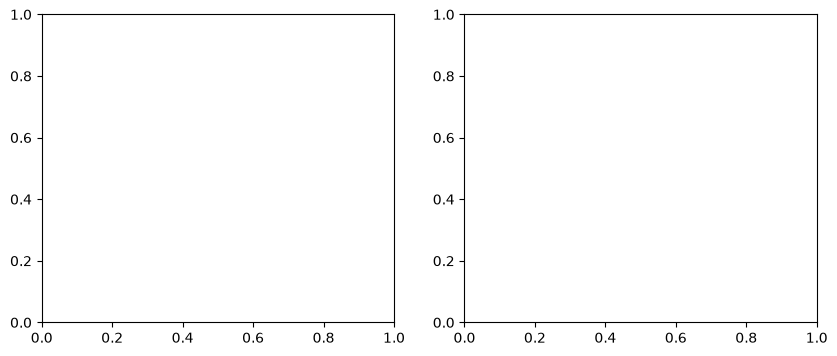

In [ ]:
# ---------- Prédictions train et final ----------
train_scores = optimized_model.predict_proba(X_train)[:, 1]
final_scores = optimized_model.predict_proba(X_final)[:, 1]

train_predictions = (train_scores >= BEST_THRESHOLD).astype(int)
final_predictions = (final_scores >= BEST_THRESHOLD).astype(int)

# ---------- Comparaison des performances ----------
train_metrics = evaluate_predictions(
    y_train, train_predictions, train_scores
)
final_metrics = evaluate_predictions(
    y_final, final_predictions, final_scores
)

evaluation_results = pd.DataFrame(
    [train_metrics, final_metrics],
    index=["train", "final"],
)
display(evaluation_results)

# ---------- Matrices de confusion ----------
_, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    train_predictions,
    labels=[0, 1],
    display_labels=["Classe 0", "Classe 1"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Données d'entraînement")

ConfusionMatrixDisplay.from_predictions(
    y_final,
    final_predictions,
    labels=[0, 1],
    display_labels=["Classe 0", "Classe 1"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Données finales jamais vues")

plt.tight_layout()
plt.show()

## Tracking MLflow et conclusion

Cette dernière cellule enregistre uniquement les résultats déjà calculés. Elle ne relance ni la recherche d'hyperparamètres ni l'entraînement.

In [ ]:
# ---------- Tracking MLflow final ----------
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("credit_scoring")

with mlflow.start_run(run_name="lightgbm_optimized_final"):
    mlflow.set_tags({
        "stage": "final_optimization",
        "objective": "business_cost",
        "description": "LightGBM optimisé avec GridSearchCV et seuil métier",
    })

    mlflow.log_params({
        **BEST_GRID_PARAMS,
        "best_threshold": BEST_THRESHOLD,
        "cv_folds": CV.get_n_splits(),
        "cost_fn": FN_COST,
        "cost_fp": FP_COST,
    })

    mlflow.log_metrics({
        "best_cv_business_cost": BEST_CV_BUSINESS_COST,
        "final_business_cost": final_metrics["business_cost"],
        "fn": final_metrics["fn"],
        "fp": final_metrics["fp"],
        "recall": final_metrics["recall"],
        "f1_score": final_metrics["f1_score"],
        "roc_auc": final_metrics["roc_auc"],
    })

print("Run MLflow enregistré : lightgbm_optimized_final")

### Lecture des résultats

Le modèle final doit réduire le coût métier et les faux négatifs sans provoquer une hausse disproportionnée des faux positifs. Le ROC AUC vérifie la qualité globale du classement, tandis que le recall et le F1-score complètent l'interprétation du seuil retenu.